In [14]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

In [15]:
# Generate 3 Gaussian blobs
N = 150

cluster1 = np.random.randn(N,2) + np.array([0,0])
cluster2 = np.random.randn(N,2) + np.array([5,5])
cluster3 = np.random.randn(N,2) + np.array([0,6])

X = np.vstack([cluster1, cluster2, cluster3])

In [16]:
def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:,None,:] - centroids[None,:,:], axis=2)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, K):
    return np.array([X[labels==k].mean(axis=0) for k in range(K)])

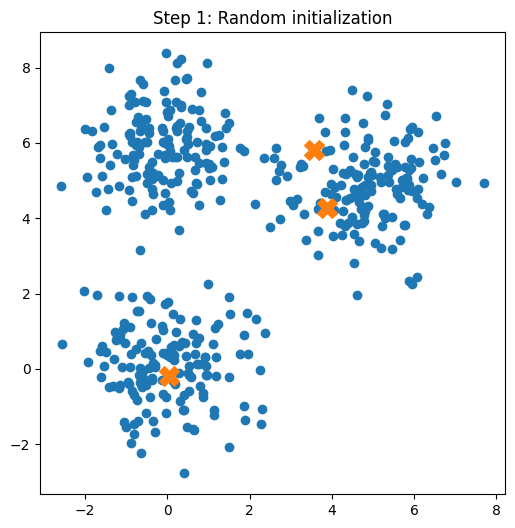

In [17]:
# Step 1: initialize centroids
K = 3
indices = np.random.choice(len(X), K, replace=False)
centroids = X[indices]

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1])
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200)
plt.title("Step 1: Random initialization")
plt.savefig("kmeans_step1.png")
plt.show()

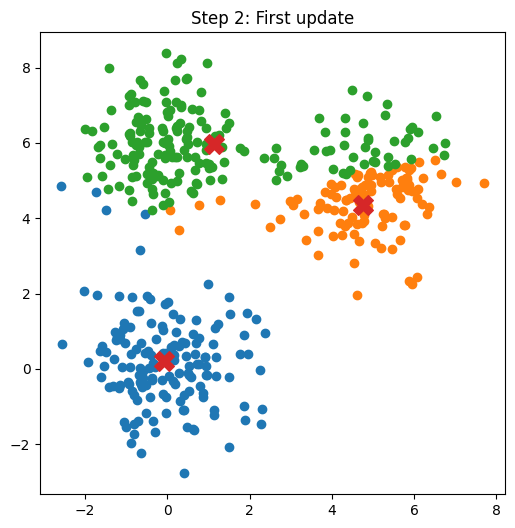

In [18]:
# Step 2: first assignment + update
labels = assign_clusters(X, centroids)
new_centroids = update_centroids(X, labels, K)

plt.figure(figsize=(6,6))
for k in range(K):
    plt.scatter(X[labels==k,0], X[labels==k,1])
plt.scatter(new_centroids[:,0], new_centroids[:,1], marker='X', s=200)
plt.title("Step 2: First update")
plt.savefig("kmeans_step2.png")
plt.show()

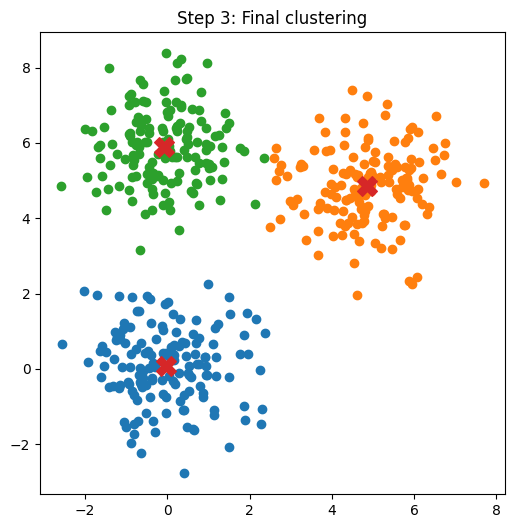

In [19]:
# Step 3: iterate until convergence
centroids = new_centroids.copy()

for i in range(10):
    labels = assign_clusters(X, centroids)
    centroids = update_centroids(X, labels, K)

plt.figure(figsize=(6,6))
for k in range(K):
    plt.scatter(X[labels==k,0], X[labels==k,1])
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200)
plt.title("Step 3: Final clustering")
plt.savefig("kmeans_step3.png")
plt.show()